In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import string
import re
import nltk
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [2]:
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/anshumaansoni/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [3]:
url = 'https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv'
df = pd.read_csv(url, sep='	', header=None, names=['label', 'text'])
df.head()

,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   label   5572 non-null   str  
 1   text    5572 non-null   str  
dtypes: str(2)
memory usage: 542.9 KB


In [5]:
df['label'].value_counts()

label
ham     4825
spam     747
Name: count, dtype: int64

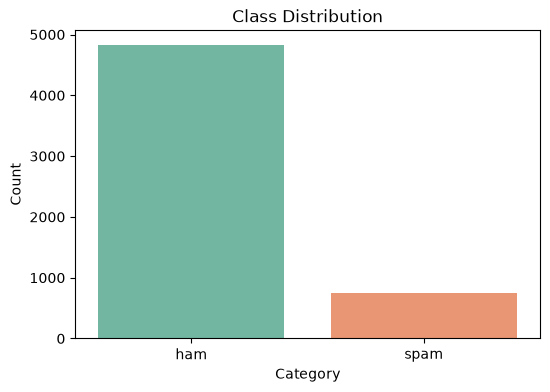

In [6]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='label', hue='label', palette='Set2', legend=False)
plt.title('Class Distribution')
plt.xlabel('Category')
plt.ylabel('Count')
plt.show()

In [7]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\d+', '', text)
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return ' '.join(words)

df['clean_text'] = df['text'].apply(clean_text)
df['target'] = df['label'].map({'ham': 0, 'spam': 1})
df[['text', 'clean_text', 'target']].head()

,text,clean_text,target
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...,0
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni,0
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry wkly comp win fa cup final tkts st ...,1
3,U dun say so early hor... U c already then say...,u dun say early hor u c already say,0
4,"Nah I don't think he goes to usf, he lives aro...",nah dont think goes usf lives around though,0


In [8]:
X = df['clean_text']
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
len(X_train), len(X_test)

(4457, 1115)

In [9]:
tfidf = TfidfVectorizer(max_features=3000)
X_train_vec = tfidf.fit_transform(X_train)
X_test_vec = tfidf.transform(X_test)

X_train_vec.shape, X_test_vec.shape

((4457, 3000), (1115, 3000))

In [10]:
models = {
    'Logistic Regression': LogisticRegression(),
    'Multinomial Naive Bayes': MultinomialNB(),
    'Support Vector Machine': SVC(kernel='linear'),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5)
}

In [11]:
results = []
predictions = {}

for name, model in models.items():
    model.fit(X_train_vec, y_train)
    y_pred = model.predict(X_test_vec)
    predictions[name] = y_pred
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1
    })

results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.970404,1.000000,0.778523,0.875472
1,Multinomial Naive Bayes,0.970404,0.991525,0.785235,0.876404
2,Support Vector Machine,0.982063,0.984962,0.879195,0.929078
3,Decision Tree,0.947982,0.805369,0.805369,0.805369
4,Random Forest,0.976682,1.000000,0.825503,0.904412
5,K-Nearest Neighbors,0.918386,1.000000,0.389262,0.560386


In [12]:
for name in models:
    print(f'=== {name} ===')
    print(classification_report(y_test, predictions[name], target_names=['ham', 'spam']))
    print()

=== Logistic Regression ===
              precision    recall  f1-score   support

         ham       0.97      1.00      0.98       966
        spam       1.00      0.78      0.88       149

    accuracy                           0.97      1115
   macro avg       0.98      0.89      0.93      1115
weighted avg       0.97      0.97      0.97      1115


=== Multinomial Naive Bayes ===
              precision    recall  f1-score   support

         ham       0.97      1.00      0.98       966
        spam       0.99      0.79      0.88       149

    accuracy                           0.97      1115
   macro avg       0.98      0.89      0.93      1115
weighted avg       0.97      0.97      0.97      1115


=== Support Vector Machine ===
              precision    recall  f1-score   support

         ham       0.98      1.00      0.99       966
        spam       0.98      0.88      0.93       149

    accuracy                           0.98      1115
   macro avg       0.98      0.94  

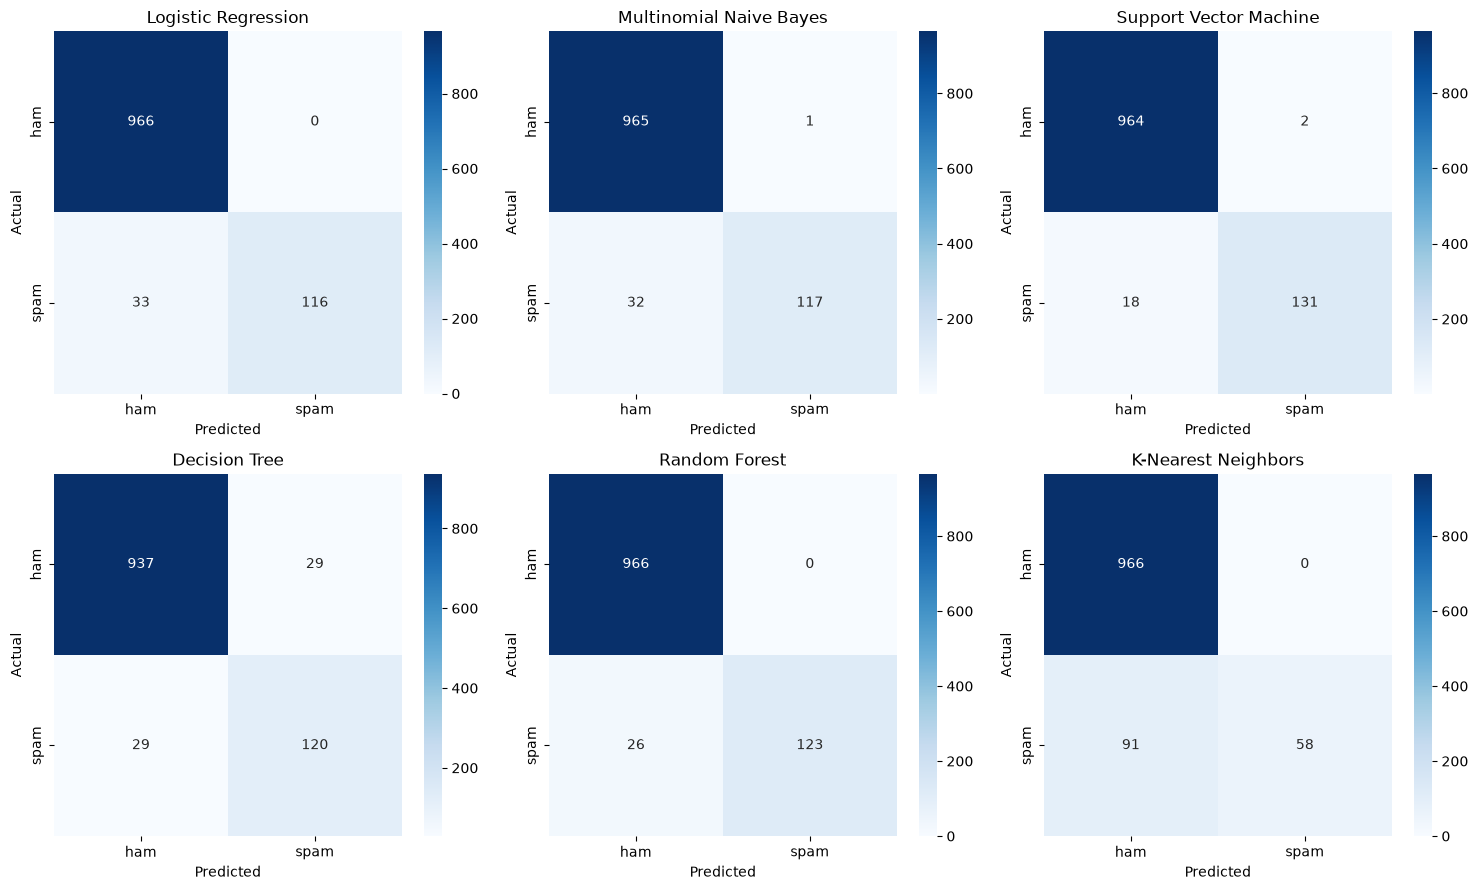

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, (name, y_pred) in enumerate(predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['ham', 'spam'], yticklabels=['ham', 'spam'])
    axes[i].set_title(name)
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

plt.tight_layout()
plt.show()

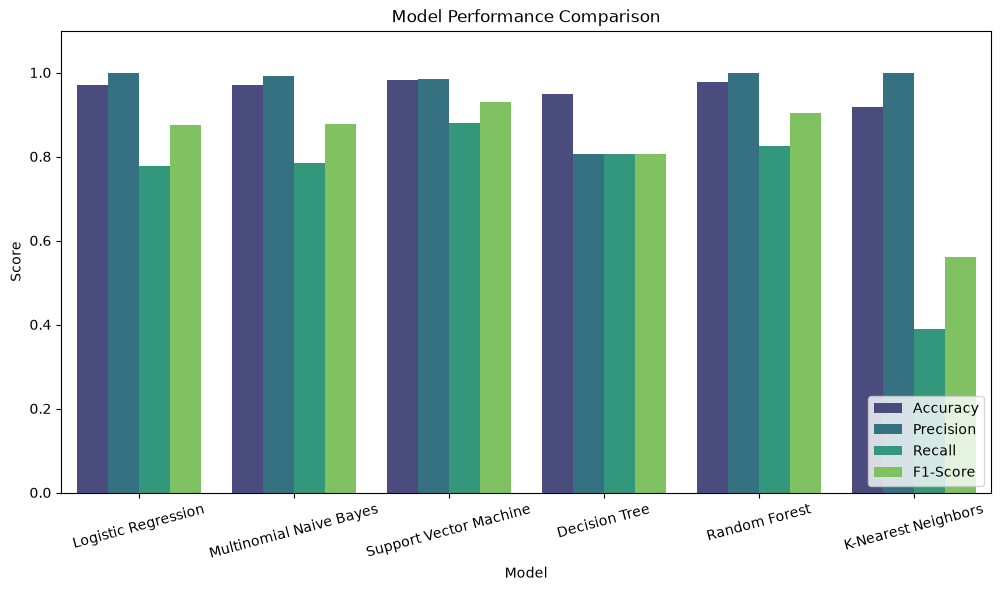

In [14]:
results_melted = results_df.melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(12, 6))
sns.barplot(data=results_melted, x='Model', y='Score', hue='Metric', palette='viridis')
plt.title('Model Performance Comparison')
plt.ylim(0, 1.1)
plt.ylabel('Score')
plt.xticks(rotation=15)
plt.legend(loc='lower right')
plt.show()

In [15]:
best_model = results_df.sort_values(by='F1-Score', ascending=False).iloc[0]

print(f'Best Performing Model: {best_model["Model"]}')
print(f'Accuracy:  {best_model["Accuracy"]:.4f}')
print(f'Precision: {best_model["Precision"]:.4f}')
print(f'Recall:    {best_model["Recall"]:.4f}')
print(f'F1-Score:  {best_model["F1-Score"]:.4f}')
print()
print(f'Justification: {best_model["Model"]} achieved the highest overall performance on the test set with an F1-Score of {best_model["F1-Score"]:.4f} and Accuracy of {best_model["Accuracy"]:.4f}. It balances high precision ({best_model["Precision"]:.4f}) and high recall ({best_model["Recall"]:.4f}), minimizing both false positives and false negatives, making it the most reliable classifier for this text classification task.')

Best Performing Model: Support Vector Machine
Accuracy:  0.9821
Precision: 0.9850
Recall:    0.8792
F1-Score:  0.9291

Justification: Support Vector Machine achieved the highest overall performance on the test set with an F1-Score of 0.9291 and Accuracy of 0.9821. It balances high precision (0.9850) and high recall (0.8792), minimizing both false positives and false negatives, making it the most reliable classifier for this text classification task.
